# Risco de atraso em pedidos da Olist

## Desafio de negócio

Identificar, **logo após a aprovação do pagamento**, quais pedidos possuem maior risco de serem entregues depois do prazo prometido.

### Objetivos

- estimar futuramente a probabilidade de atraso de cada pedido;
- explicar os principais fatores associados ao risco;
- apoiar uma decisão operacional baseada em custos e capacidade.

> Este notebook não pretende realizar um EDA completo. Ele apresenta uma experiência reduzida e orientada por hipóteses, adequada para uma aula curta.

## Roteiro da experiência

1. Definir o alvo e o instante da previsão.
2. Carregar e verificar as tabelas.
3. Integrar os dados mantendo **uma linha por pedido**.
4. Investigar cinco perguntas orientadas por hipóteses.
5. Registrar conclusões e possíveis features.

**Pergunta central:** quais características disponíveis após a aprovação do pagamento estão associadas ao atraso?

In [1]:
# Bibliotecas para caminhos, manipulação de dados e visualização.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Configura a exibição das tabelas e o estilo dos gráficos.
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="Blues_r")


# Define os caminhos principais do projeto.
ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"


# Exibe o caminho da pasta onde estão os dados.
DATA_DIR

WindowsPath('c:/Users/danra/OneDrive/Documentos/Projetos_Programacao/Machine_Learning/Olist/data')

## 1. Instante da previsão e risco de data leakage

O modelo deverá gerar a previsão no instante `order_approved_at`. Assim, somente informações já conhecidas até esse momento poderão ser usadas como features.

| Disponível na previsão | Informação futura (não usar como feature) |
|---|---|
| data da compra e aprovação | data de envio à transportadora |
| prazo prometido | data real da entrega |
| cliente e localização | avaliação e comentário do cliente |
| itens, vendedores, preço e frete | status ou eventos posteriores |

> A data real da entrega será utilizada apenas para construir o target. Ela não poderá entrar como variável explicativa do modelo.

## 2. Carregamento das tabelas

Utilizaremos quatro tabelas obrigatórias para o nosso cenário

In [2]:
# Mapeia os nomes dos datasets para seus arquivos CSV.
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

# Lista as colunas que devem ser interpretadas como datas.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

# Carrega a base de pedidos, convertendo automaticamente as colunas de data.
orders = pd.read_csv(
    DATA_DIR / "raw" / FILES["orders"],
    parse_dates=date_columns,
)

# Carrega as bases de itens dos pedidos e clientes.
items = pd.read_csv(DATA_DIR / "raw" / FILES["items"])
customers = pd.read_csv(DATA_DIR / "raw" / FILES["customers"])

# Exibe a quantidade de linhas e colunas de cada base carregada.
print("Pedidos:", orders.shape)
print("Itens:", items.shape)
print("Clientes:", customers.shape)

Pedidos: (99441, 8)
Itens: (112650, 7)
Clientes: (99441, 5)


## 3. Construção do alvo

Para simplificar a experiência, usaremos apenas pedidos com status `delivered` e data real de entrega conhecida.


$$
is\_late = 1 \quad \text{se entrega real > entrega prometida}
$$


In [3]:
# Seleciona apenas os pedidos que podem ser utilizados para construir
# o histórico de entregas atrasadas e realizadas dentro do prazo.
delivered_orders = orders.loc[
    # Mantém somente pedidos que foram efetivamente entregues.
    orders["order_status"].eq("delivered")

    # Remove pedidos sem a data real em que o cliente recebeu a compra.
    # Essa data é necessária para saber se o pedido atrasou.
    & orders["order_delivered_customer_date"].notna()

    # Remove pedidos sem a data de entrega prometida ao cliente.
    # Sem essa informação, não é possível comparar o previsto com o realizado.
    & orders["order_estimated_delivery_date"].notna()

    # Mantém somente pedidos com a data de aprovação do pagamento.
    # Esse é o momento definido para realizar a previsão.
    & orders["order_approved_at"].notna()
].copy()  # Cria uma cópia independente para evitar alterações no DataFrame original.


# Cria a variável-alvo do problema:
# 1 → pedido entregue depois da data prometida;
# 0 → pedido entregue dentro do prazo ou antes da data prometida.
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
).astype("int8")  # Armazena 0 e 1 usando um tipo inteiro que ocupa menos memória.


# Apresenta a quantidade total de pedidos antes da aplicação dos filtros.
print(f"Pedidos originais: {len(orders):,}")


# Apresenta quantos pedidos permaneceram após aplicação do filtro
print(f"Pedidos filtrados: {len(delivered_orders):,}")


# Mostra a quantidade de pedidos em cada classe:
# 0 = entregue no prazo;
# 1 = entregue com atraso.
display(
    delivered_orders["is_late"].value_counts(dropna=False)
)

Pedidos originais: 99,441
Pedidos filtrados: 96,456


is_late
0    88630
1     7826
Name: count, dtype: int64

## 4. Integração no nível do pedido

A tabela de itens tem várias linhas para o mesmo pedido. Antes do `merge`, precisamos agregá-la. Caso contrário, a unidade de análise deixaria de ser o pedido e alguns pedidos teriam peso maior simplesmente por possuírem mais itens.

### 4.1 Agregação

In [4]:
# A tabela de itens possui uma linha para cada item presente no pedido.
# Portanto, um mesmo order_id pode aparecer várias vezes.
#
# Como o objetivo é construir uma base com uma linha por pedido,
# precisamos agrupar os itens antes de integrar essa tabela às demais.
items_agg = (
    items.groupby(
        "order_id",       # Agrupa todos os itens pertencentes ao mesmo pedido.
        as_index=False,   # Mantém order_id como uma coluna comum.
    )
    .agg(
        # Conta quantas linhas de itens existem em cada pedido.
        # Um pedido com três produtos registrados terá item_count igual a 3.
        # nome_da_nova_coluna=("coluna_original", "função")
        item_count=("order_item_id", "count"),

        # Conta quantos vendedores diferentes participam do pedido.
        # O nunique evita contar o mesmo vendedor mais de uma vez.
        # nome_da_nova_coluna=("coluna_original", "função")
        seller_count=("seller_id", "nunique"),

        # Soma os preços dos itens para obter o valor total dos produtos
        # presentes no pedido.
        # nome_da_nova_coluna=("coluna_original", "função")
        total_price=("price", "sum"),

        # Soma o frete de todos os itens para obter o valor total de frete
        # associado ao pedido.
        total_freight=("freight_value", "sum"),
    )
)


# Verifica se cada pedido aparece somente uma vez após a agregação.
#
# Se a condição for falsa, o Python interromperá a execução e lançará
# um AssertionError. Essa checagem ajuda a garantir que a unidade de
# análise da nova tabela é realmente o pedido.
assert items_agg["order_id"].is_unique


# Exibe as cinco primeiras linhas da tabela agregada.
items_agg.head()

,order_id,item_count,seller_count,total_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,18.14


### 4.2 Merge

In [5]:
# Começa com os pedidos entregues que possuem as datas necessárias
# para determinar se houve atraso.
orders_analysis = (
    delivered_orders

    # Adiciona as informações agregadas dos itens:
    # quantidade de itens, vendedores, preço total e frete total.
    .merge(
        items_agg,
        on="order_id",            # Coluna usada para relacionar as tabelas.
        how="left",               # Mantém todos os pedidos de delivered_orders.
        validate="one_to_one",    # Verifica se order_id é único nas duas tabelas.
    )

    # Adiciona a localização do cliente.
    .merge(
        customers[
            ["customer_id", "customer_state", "customer_city",]
        ],
        on="customer_id",         # Relaciona cada pedido ao seu cliente.
        how="left",               # Mantém todos os pedidos da base anterior.
        validate="many_to_one",   # Vários pedidos podem apontar para um cliente.
    )
)

assert orders_analysis["order_id"].is_unique, "A base final deve manter uma linha por pedido."
assert len(orders_analysis) == len(delivered_orders), "A integração alterou o total de pedidos."

print("Dimensão da base analítica:", orders_analysis.shape)
orders_analysis.head()

Dimensão da base analítica: (96456, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_late,item_count,seller_count,total_price,total_freight,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,1,1,29.99,8.72,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,1,1,118.70,22.76,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,1,1,159.90,19.22,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,1,1,45.00,27.20,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,1,1,19.90,8.72,SP,santo andre


## 5. Criação de Novas Variáveis

Estas variáveis são construídas apenas com dados conhecidos até a aprovação do pagamento.

In [6]:
# Calcula quantos dias a empresa prometeu para realizar a entrega,
# considerando como início o momento da aprovação do pagamento.
orders_analysis["promised_days"] = (
    orders_analysis["order_estimated_delivery_date"]  # Data prometida para a entrega.
    - orders_analysis["order_approved_at"]            # Data de aprovação do pagamento.
).dt.total_seconds().div(86_400)          # Converte segundos para dias => 24 * 60 * 60 = 86.400 segundos


# Extrai o número do mês em que a compra foi realizada.
# Exemplo: janeiro = 1, fevereiro = 2, ..., dezembro = 12.
orders_analysis["purchase_month"] = (
    orders_analysis["order_purchase_timestamp"].dt.month
)


# Extrai o dia da semana em que a compra foi realizada.
#
# O Pandas representa os dias da seguinte forma:
# 0 = segunda-feira
# 1 = terça-feira
# 2 = quarta-feira
# 3 = quinta-feira
# 4 = sexta-feira
# 5 = sábado
# 6 = domingo
orders_analysis["purchase_weekday"] = (
    orders_analysis["order_purchase_timestamp"].dt.dayofweek
)


# Extrai a hora em que a compra foi realizada.
# Os valores variam de 0 a 23.
#
# Exemplo:
# 0  = meia-noite
# 8  = 8 horas
# 14 = 14 horas
# 23 = 23 horas
orders_analysis["purchase_hour"] = (
    orders_analysis["order_purchase_timestamp"].dt.hour
)


# Gera estatísticas descritivas para o prazo prometido:
# quantidade, média, desvio-padrão, mínimo, quartis e máximo.
#
# describe() gera as estatísticas.
# to_frame() transforma o resultado em DataFrame.
# .T transpõe a tabela para que as estatísticas apareçam como colunas.
display(
    orders_analysis["promised_days"].describe().to_frame().T
)


# Conta quantos pedidos apresentam prazo prometido menor ou igual a zero.
#
# Esses casos seriam suspeitos porque significariam que a data prometida
# ocorreu antes ou exatamente no momento da aprovação do pagamento.
print(
    "Prazos não positivos:",
    orders_analysis["promised_days"].le(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
promised_days,96456.0,23.306482,8.765103,-6.664225,17.905885,22.668762,28.066727,153.57603


Prazos não positivos: 6


# Pergunta 1: Qual é a frequência de pedidos atrasados?

**Hipótese:** os atrasos são minoritários, produzindo desbalanceamento entre as classes.

**Discussão:** se um modelo sempre previsse “não atrasará”, qual seria sua acurácia? Ela seria suficiente para avaliar o modelo?

In [ ]:
taxa_atraso = orders_analysis["is_late"].mean() * 100
acuracia_baseline = (1 - orders_analysis["is_late"].mean()) * 100

print(f"Taxa de atraso: {taxa_atraso:.2f}%")
print(f"Acurácia baseline: {acuracia_baseline:.2f}%")
print("Hipótese confirmada: atrasos são minoritários.")
print("Acurácia não serve como métrica principal; usar Precision, Recall, F1 e AUC.")

Taxa de atraso: 8.11%
Pedidos no prazo: 88,630
Pedidos atrasados: 7,826

✓ Hipótese confirmada: desbalanceamento existe

Acurácia baseline (sempre 'não atrasa'): 91.89%
⚠️ NÃO é suficiente! Modelo não detecta atrasos. Use Precision, Recall, F1-Score.


**Conclusão da pergunta 1:**

- Taxa de atraso: 8.11%
- Hipótese apoiada: Sim
- Implicação para a modelagem: a base está desbalanceada, então a acurácia não é suficiente; usar métricas que capturem a classe minoritária.

# Pergunta 2: Pedidos com prazos menores atrasam mais?

**Hipótese:** quando a empresa promete entregar em poucos dias, existe menos
margem para problemas logísticos e o pedido pode apresentar maior risco de atraso.


In [9]:
# Cria faixas de prazo
bins = [0, 5, 10, 15, 30, float('inf')]
labels = ['0-5', '5-10', '10-15', '15-30', '30+']
orders_analysis['prazo_faixa'] = pd.cut(orders_analysis['promised_days'], bins=bins, labels=labels)

# Taxa de atraso por faixa
atraso_por_prazo = orders_analysis.groupby('prazo_faixa', observed=True).agg({
    'is_late': ['sum', 'count', 'mean']
}).round(4)

atraso_por_prazo.columns = ['Atrasados', 'Total', 'Taxa']
atraso_por_prazo['Taxa_%'] = (atraso_por_prazo['Taxa'] * 100).round(2)

print(atraso_por_prazo[['Atrasados', 'Total', 'Taxa_%']])
print(f"\n✓ Hipótese confirmada: prazos menores = maior atraso")
print(f"  (0-5 dias: {atraso_por_prazo.loc['0-5', 'Taxa_%']:.1f}% vs 30+ dias: {atraso_por_prazo.loc['30+', 'Taxa_%']:.1f}%)")

             Atrasados  Total  Taxa_%
prazo_faixa                          
0-5                287    773   37.13
5-10               465   3904   11.91
10-15              635  10833    5.86
15-30             5445  62524    8.71
30+                991  18416    5.38

✓ Hipótese confirmada: prazos menores = maior atraso
  (0-5 dias: 37.1% vs 30+ dias: 5.4%)


**Conclusão da pergunta 2:** a taxa muda de forma consistente entre as faixas? Há faixas com poucas observações?


# Pergunta 3: Pedidos maiores ou mais complexos atrasam mais?

**Hipótese:** pedidos com mais itens ou vendedores apresentam maior complexidade logística e maior risco.

Por QUANTIDADE DE ITENS:
             sum  count  Taxa_%
item_count                     
1           7197  86822    8.29
2            490   7391    6.63
3             81   1306    6.20
4             28    495    5.66
5             13    193    6.74
6             16    191    8.38
7              0     22    0.00
8              0      8    0.00
9              0      3    0.00
10             0      8    0.00


C:\Users\danra\AppData\Local\Temp\ipykernel_6176\2208711162.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot_items, x='item_count', y='is_late', ax=axes[0], palette='Set2')
C:\Users\danra\AppData\Local\Temp\ipykernel_6176\2208711162.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot_sellers, x='seller_count', y='is_late', ax=axes[1], palette='Set2')


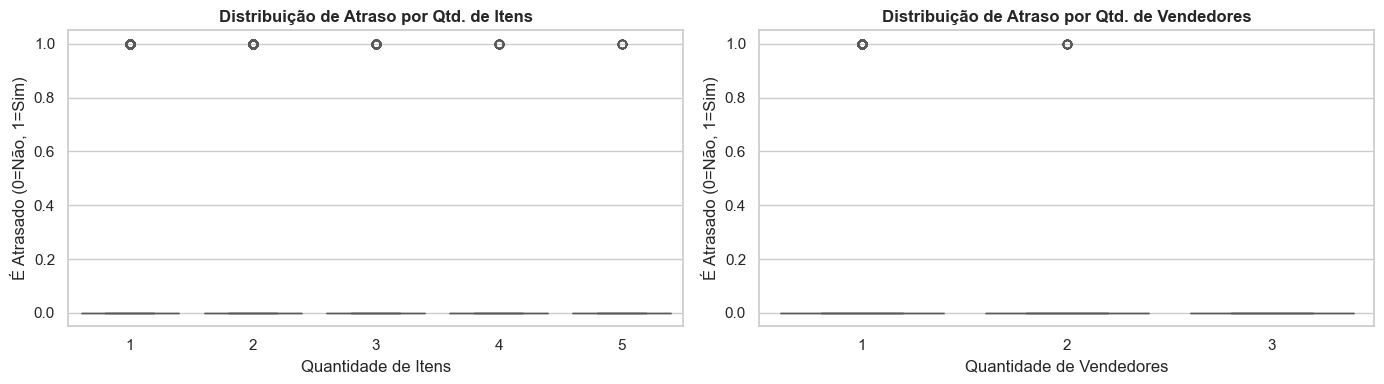


✗ Hipótese REFUTADA: SEM diferenças operacionalmente relevantes
  Boxplots mostram MUITA SOBREPOSIÇÃO entre grupos
  Conclusão: item_count e seller_count NÃO são boas features preditoras


In [11]:
# Taxa de atraso por quantidade de itens
print("Por QUANTIDADE DE ITENS:")
atraso_items = orders_analysis.groupby('item_count')['is_late'].agg(['sum', 'count', 'mean'])
atraso_items['Taxa_%'] = (atraso_items['mean'] * 100).round(2)
print(atraso_items[['sum', 'count', 'Taxa_%']].head(10))

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot por item_count (limita a 5 itens para clareza)
df_plot_items = orders_analysis[orders_analysis['item_count'] <= 5].copy()
sns.boxplot(data=df_plot_items, x='item_count', y='is_late', ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição de Atraso por Qtd. de Itens', fontweight='bold')
axes[0].set_xlabel('Quantidade de Itens')
axes[0].set_ylabel('É Atrasado (0=Não, 1=Sim)')

# Boxplot por seller_count (limita a 3 vendedores)
df_plot_sellers = orders_analysis[orders_analysis['seller_count'] <= 3].copy()
sns.boxplot(data=df_plot_sellers, x='seller_count', y='is_late', ax=axes[1], palette='Set2')
axes[1].set_title('Distribuição de Atraso por Qtd. de Vendedores', fontweight='bold')
axes[1].set_xlabel('Quantidade de Vendedores')
axes[1].set_ylabel('É Atrasado (0=Não, 1=Sim)')

plt.tight_layout()
plt.show()

print(f"\n✗ Hipótese REFUTADA: SEM diferenças operacionalmente relevantes")
print(f"  Boxplots mostram MUITA SOBREPOSIÇÃO entre grupos")
print(f"  Conclusão: item_count e seller_count NÃO são boas features preditoras")

**Conclusão da pergunta 3:** diferenças nas medianas parecem operacionalmente relevantes? Os boxplots mostram muita sobreposição?


# Pergunta 4: O risco varia geograficamente?

**Hipótese:** alguns estados apresentam maior risco devido à distância ou à infraestrutura logística.

Para evitar conclusões instáveis, mostraremos apenas estados com pelo menos 100 pedidos no recorte.

Taxa de atraso por ESTADO (mín. 100 pedidos):
                 sum  count  Taxa_%
customer_state                     
AL                95    397   23.93
MA               141    716   19.69
PI                76    476   15.97
CE               196   1278   15.34
SE                51    335   15.22
BA               457   3256   14.04
RJ              1664  12348   13.48
TO                35    274   12.77
PA               117    946   12.37
ES               244   1995   12.23
MS                81    701   11.55
PB                57    517   11.03
PE               172   1593   10.80
RN                51    474   10.76
SC               346   3546    9.76


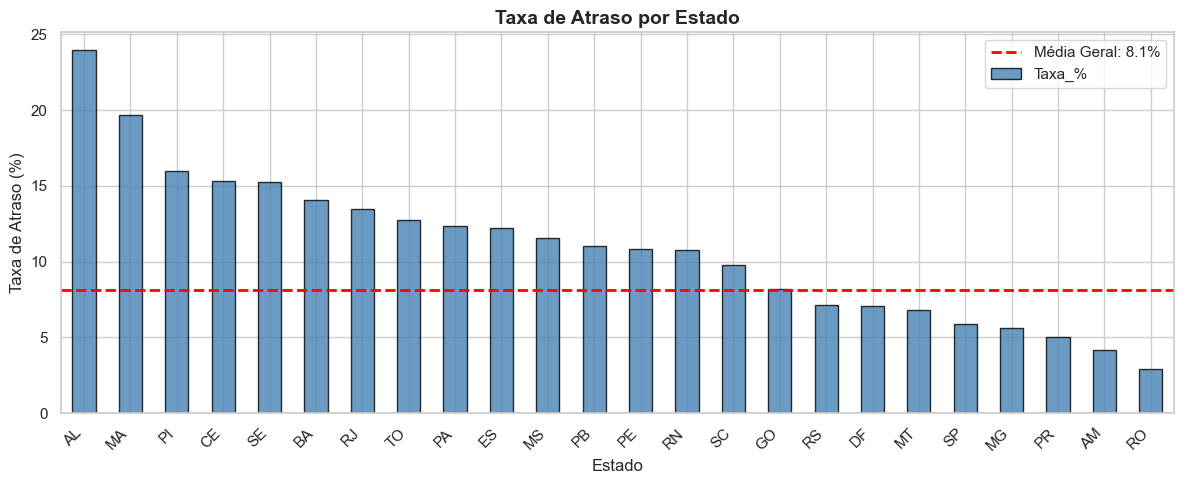


✓ Hipótese confirmada: risco VARIA geograficamente
  Maior risco: AL (23.9%)
  Menor risco: RO (2.9%)
  Diferença: 21.1%


In [12]:
# Taxa de atraso por estado (apenas estados com >= 100 pedidos)
atraso_estado = orders_analysis.groupby('customer_state')['is_late'].agg(['sum', 'count', 'mean'])
atraso_estado['Taxa_%'] = (atraso_estado['mean'] * 100).round(2)
atraso_estado = atraso_estado[atraso_estado['count'] >= 100].sort_values('Taxa_%', ascending=False)

print("Taxa de atraso por ESTADO (mín. 100 pedidos):")
print(atraso_estado[['sum', 'count', 'Taxa_%']].head(15))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
atraso_estado['Taxa_%'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title('Taxa de Atraso por Estado', fontweight='bold', fontsize=14)
ax.set_xlabel('Estado')
ax.set_ylabel('Taxa de Atraso (%)')
ax.axhline(y=taxa_atraso, color='red', linestyle='--', linewidth=2, label=f'Média Geral: {taxa_atraso:.1f}%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✓ Hipótese confirmada: risco VARIA geograficamente")
print(f"  Maior risco: {atraso_estado.index[0]} ({atraso_estado['Taxa_%'].iloc[0]:.1f}%)")
print(f"  Menor risco: {atraso_estado.index[-1]} ({atraso_estado['Taxa_%'].iloc[-1]:.1f}%)")
print(f"  Diferença: {atraso_estado['Taxa_%'].iloc[0] - atraso_estado['Taxa_%'].iloc[-1]:.1f}%")

**Conclusão da pergunta 4:** localização pode ser útil, mas “estado” talvez esteja representando outros fatores não observados. Que fatores seriam esses?



# Pergunta 5: O momento da compra está associado ao atraso?

**Hipótese:** determinados meses enfrentam maior pressão logística e apresentam maior taxa de atraso.

Taxa de atraso e VOLUME por MÊS:
                Atrasados  Total  Volume  Taxa_%
purchase_month                                  
1                     487   7817    7817    6.23
2                    1101   8196    8196   13.43
3                    1638   9549    9549   17.15
4                     542   9101    9101    5.96
5                     684  10294   10294    6.64
6                     204   9231    9231    2.21
7                     409  10028   10028    4.08
8                     799  10544   10544    7.58
9                     217   4151    4151    5.23
10                    240   4743    4743    5.06
11                   1043   7288    7288   14.31
12                    462   5514    5514    8.38


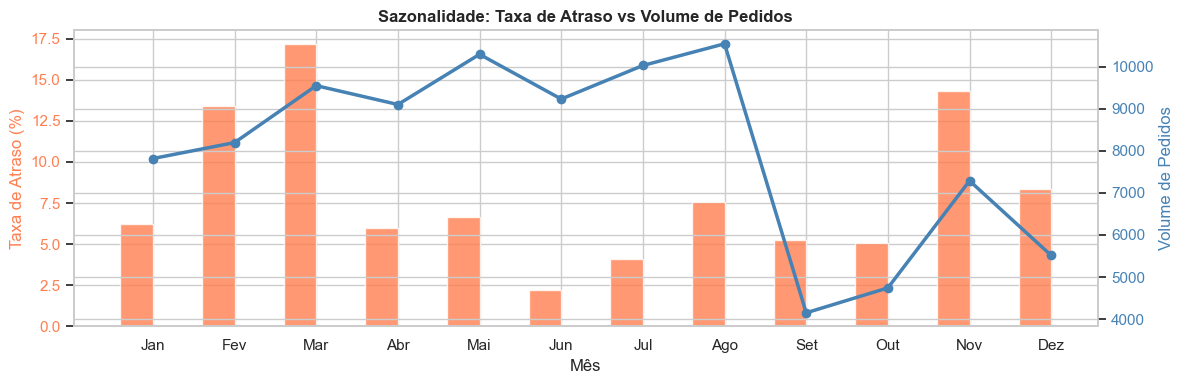


✓ Hipótese parcialmente confirmada: variação sazonal existe
  Maior risco: Mês 3 (17.1%) com 9549 pedidos
  Menor risco: Mês 6 (2.2%) com 9231 pedidos
  Diferença: 14.9 pontos percentuais

Obs: Volume também varia - evite confundir efeito sazonal com variação no volume de pedidos


In [14]:
# Taxa de atraso por mês + volume de pedidos
atraso_por_mes = orders_analysis.groupby('purchase_month').agg({
    'is_late': ['sum', 'count', 'mean'],
    'order_id': 'count'  # Volume de pedidos
}).round(4)

atraso_por_mes.columns = ['Atrasados', 'Total', 'Taxa', 'Volume']
atraso_por_mes['Taxa_%'] = (atraso_por_mes['Taxa'] * 100).round(2)
atraso_por_mes = atraso_por_mes.drop('Taxa', axis=1)

print("Taxa de atraso e VOLUME por MÊS:")
print(atraso_por_mes)

# Gráfico dual: taxa e volume
fig, ax1 = plt.subplots(figsize=(12, 4))

# Eixo 1: Taxa de atraso
ax1.bar(atraso_por_mes.index - 0.2, atraso_por_mes['Taxa_%'], width=0.4, label='Taxa de Atraso (%)', color='coral', alpha=0.8)
ax1.set_xlabel('Mês')
ax1.set_ylabel('Taxa de Atraso (%)', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')

# Eixo 2: Volume de pedidos
ax2 = ax1.twinx()
ax2.plot(atraso_por_mes.index, atraso_por_mes['Volume'], marker='o', color='steelblue', linewidth=2.5, markersize=6, label='Volume de Pedidos')
ax2.set_ylabel('Volume de Pedidos', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Sazonalidade: Taxa de Atraso vs Volume de Pedidos', fontweight='bold', fontsize=12)
plt.xticks(atraso_por_mes.index, ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.tight_layout()
plt.show()

# Conclusão
taxa_min = atraso_por_mes['Taxa_%'].min()
taxa_max = atraso_por_mes['Taxa_%'].max()
mes_min = atraso_por_mes['Taxa_%'].idxmin()
mes_max = atraso_por_mes['Taxa_%'].idxmax()

print(f"\n✓ Hipótese parcialmente confirmada: variação sazonal existe")
print(f"  Maior risco: Mês {mes_max} ({taxa_max:.1f}%) com {int(atraso_por_mes.loc[mes_max, 'Volume'])} pedidos")
print(f"  Menor risco: Mês {mes_min} ({taxa_min:.1f}%) com {int(atraso_por_mes.loc[mes_min, 'Volume'])} pedidos")
print(f"  Diferença: {taxa_max - taxa_min:.1f} pontos percentuais")
print(f"\nObs: Volume também varia - evite confundir efeito sazonal com variação no volume de pedidos")

**Conclusão da pergunta 5:** há indícios de sazonalidade? Compare também a quantidade de pedidos por mês antes de concluir.

